# AOD EDA: MODIS vs Himawari (L3 Envisoft)

Exploratory Data Analysis comparing Aerosol Optical Depth (AOD) measurements from:
- **MODIS MCD19A2** — `Optical_Depth_047` and `Optical_Depth_055`
- **Himawari L3 Envisoft** — `AOT_Merged` (primary product)

Goals:
1. Load and clean both datasets per station
2. Merge on overlapping timestamps
3. Correlation analysis (scatter plots, R², RMSE, bias)
4. Time-series comparison per station
5. Aggregate statistics across all stations

## 0 · Imports & Configuration

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

# ── Paths ──────────────────────────────────────────────────────────────────
MODIS_DIR = Path('/home/slow_data/Air_Quality/MODIS_MCD19A2/stations_aod_v3')
HIMA_DIR  = Path('/home/slow_data/Air_Quality/Himawari/station_aod_v3/L3')

# ── MODIS bands to analyse
MODIS_BANDS = ['Optical_Depth_047', 'Optical_Depth_055']

print('MODIS dir exists :', MODIS_DIR.exists())
print('Himawari dir exists:', HIMA_DIR.exists())

MODIS dir exists : True
Himawari dir exists: True


## 1 · Discover Station Files

In [2]:

# Group all CSV files per station into lists (multiple files per station)
modis_files: dict[str, list[Path]] = {}
for f in MODIS_DIR.glob('*.csv'):
    sid = f.stem
    modis_files.setdefault(sid, []).append(f)

hima_files: dict[str, list[Path]] = {}
for f in HIMA_DIR.glob('*.csv'):
    sid = f.stem
    hima_files.setdefault(sid, []).append(f)

common_ids = sorted(set(modis_files) & set(hima_files))

print(f'MODIS stations   : {len(modis_files)}')
print(f'Himawari stations: {len(hima_files)}')
print(f'Common stations  : {len(common_ids)}')
print('\nFirst 10 common IDs:')
for sid in common_ids[:10]:
    print(' ', sid)


MODIS stations   : 123
Himawari stations: 123
Common stations  : 123

First 10 common IDs:
  Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp Thành (KK)
  Bình Định: Khuôn viên Cây xanh gần cầu chui đường Hoa Lư - TP. Quy Nhơn (KK)
  Bình Định: huyện Tuy Phước (KK)
  Bắc Giang: Số 1 đ. Hùng Vương - P. Lê Lợi - TP. Bắc Giang (KK)
  Bắc Giang: Thôn Vĩnh An - xã Song Mai - TP. Bắc Giang (KK)
  Bắc Ninh: KCN Tiên Sơn (Trạm cấp nước sạch KCN) - Từ Sơn (KK)
  Bắc Ninh: KCN Yên Phong (gần trạm cấp nước sạch) (KK)
  Bắc Ninh: Khu liên cơ Thuận Thành - thị trấn Hồ (KK)
  Bắc Ninh: TT Quan trắc - phường Suối Hoa - TP Bắc Ninh (KK)
  Bắc Ninh: UBND huyện Quế Võ, TT Phố Mới (KK)


## 2 · Loader Functions

In [ ]:

def load_modis(paths: list[Path]) -> pd.DataFrame:
    """
    Load and concatenate multiple MODIS station CSVs for one station,
    returning both 0.47 and 0.55 µm time series.
    Negative / fill values are replaced with NaN.
    """
    frames = [pd.read_csv(p, parse_dates=['timestamp'], low_memory=False) for p in paths]
    df = pd.concat(frames, ignore_index=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.dropna(subset=['timestamp'])
    df = df.sort_values('timestamp').set_index('timestamp')

    # Normalize station name column
    if 'stationName' in df.columns and 'Name' not in df.columns:
        df = df.rename(columns={'stationName': 'Name'})

    out = df[[c for c in ['Name', 'Latitude', 'Longitude'] if c in df.columns]].copy()

    for band in MODIS_BANDS:
        aod = df[band].copy().astype(float)
        out[f'AOD_MODIS_{band.split("_")[-1]}'] = aod

    return out


def load_himawari(paths: list[Path]) -> pd.DataFrame:
    """
    Load and concatenate multiple Himawari L3 station CSVs for one station.
    Uses AOT_Merged only; replaces fill / negative values with NaN.
    """
    frames = [pd.read_csv(p, parse_dates=['timestamp'], low_memory=False) for p in paths]
    df = pd.concat(frames, ignore_index=True)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.dropna(subset=['timestamp'])
    df = df.sort_values('timestamp').set_index('timestamp')

    aot = df['AOT_Merged_center'].copy().astype(float)

    out = pd.DataFrame({'AOD_Himawari': aot})
    if 'QA_flag_Merged' in df.columns:
        out['QA_Himawari'] = df['QA_flag_Merged']
    if 'AE_Merged' in df.columns:
        out['AE_Himawari'] = df['AE_Merged']
    return out


print('Loader functions defined ✓')


Loader functions defined ✓


## 3 · Build Merged Dataset (all stations)

In [4]:
# print(sid)

In [5]:
# modis = load_modis(modis_files[sid])
# modis

In [6]:

records = []
station_dfs = {}   # keep per-station merged DF for later

_radius = pd.Timedelta('1h')

for sid in common_ids:
    try:
        modis = load_modis(modis_files[sid])
        hima  = load_himawari(hima_files[sid])

        # ── Align: for each MODIS overpass, average available Himawari ────
        # MODIS is typically 1–2 overpasses/day; Himawari is sub-hourly.
        # For every MODIS timestamp we take the mean of all Himawari
        # observations that fall within a ±1 h window around it.
        hima_aod = hima['AOD_Himawari']
        has_qa   = 'QA_Himawari' in hima.columns

        aod_means, qa_means = [], []
        for ts in modis.index:
            window = hima_aod.loc[ts - _radius : ts + _radius]
            aod_means.append(window.mean() if len(window) > 0 else float('nan'))
            if has_qa:
                qa_means.append(
                    hima.loc[ts - _radius : ts + _radius, 'QA_Himawari'].mode()
                    if len(window) > 0 else float('nan')
                )

        merged = modis.copy()
        merged['AOD_Himawari'] = aod_means
        if has_qa:
            merged['QA_Himawari'] = qa_means

        # Drop MODIS rows where no Himawari data fell in the ±1 h window
        merged = merged.dropna(subset=['AOD_Himawari'])

        if len(merged) == 0:
            continue

        # Attach station metadata
        for col in ['Name', 'Latitude', 'Longitude']:
            if col in modis.columns:
                merged[col] = modis[col].iloc[0] if not modis[col].empty else float('nan')
        merged['station_id'] = sid

        station_dfs[sid] = merged
        records.append(merged.reset_index())

    except Exception as e:
        print(f'[WARN] {sid}: {e}')

all_df = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
all_df['timestamp'] = pd.to_datetime(all_df['timestamp'], utc=True)

print(f'Total matched records : {len(all_df):,}')
print(f'Stations with data    : {all_df["station_id"].nunique()}')
print(f'Date range            : {all_df["timestamp"].min().date()} → {all_df["timestamp"].max().date()}')
all_df.head()


Total matched records : 19,207
Stations with data    : 121
Date range            : 2022-09-02 → 2026-03-09


,timestamp,Name,AOD_MODIS_047,AOD_MODIS_055,AOD_Himawari,QA_Himawari,station_id
0,2022-12-28 09:50:00+00:00,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",0.179,0.129,0.3248,193.0,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ..."
1,2023-02-11 09:35:00+00:00,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",0.527,0.382,0.4124,1244.0,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ..."
2,2023-02-21 09:50:00+00:00,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",0.104,0.075,0.2487,2240.5,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ..."
3,2023-02-22 10:35:00+00:00,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",0.363,0.263,0.2176,1245.0,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ..."
4,2023-02-24 10:15:00+00:00,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ...",0.337,0.244,0.2995,1217.0,"Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp ..."


## 4 · Data Overview & Missing-Value Summary

=== Basic statistics ===


,count,mean,std,min,25%,50%,75%,max
AOD_MODIS_047,19207.0,0.5191,0.3270,0.0000,0.2890,0.4530,0.6710,2.4350
AOD_MODIS_055,19207.0,0.3949,0.2544,0.0000,0.2158,0.3420,0.5110,1.8930
AOD_Himawari,19207.0,0.3722,0.2689,0.0093,0.1735,0.3014,0.5106,2.0585



Median pairs per station: 173
Stations with ≥30 pairs : 117


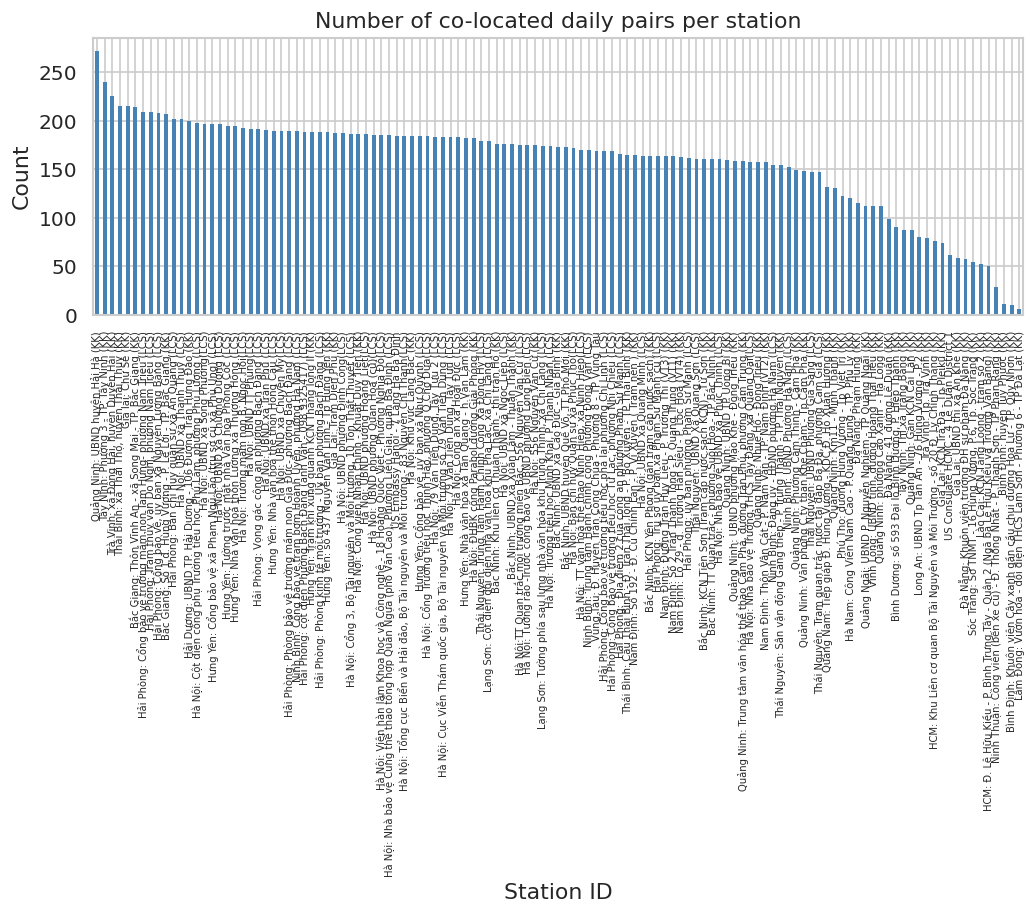

In [7]:
print('=== Basic statistics ===')
modis_cols = [f'AOD_MODIS_{band.split("_")[-1]}' for band in MODIS_BANDS]
display(all_df[modis_cols + ['AOD_Himawari']].describe().T.round(4))

# Per-station pair count
pair_counts = all_df.groupby('station_id').size().rename('n_pairs').sort_values(ascending=False)
print(f'\nMedian pairs per station: {pair_counts.median():.0f}')
print(f'Stations with ≥30 pairs : {(pair_counts >= 30).sum()}')

fig, ax = plt.subplots(figsize=(10, 3))
pair_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Number of co-located daily pairs per station')
ax.set_xlabel('Station ID'); ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
plt.tight_layout(); plt.show()

## 5 · AOD Value Distributions

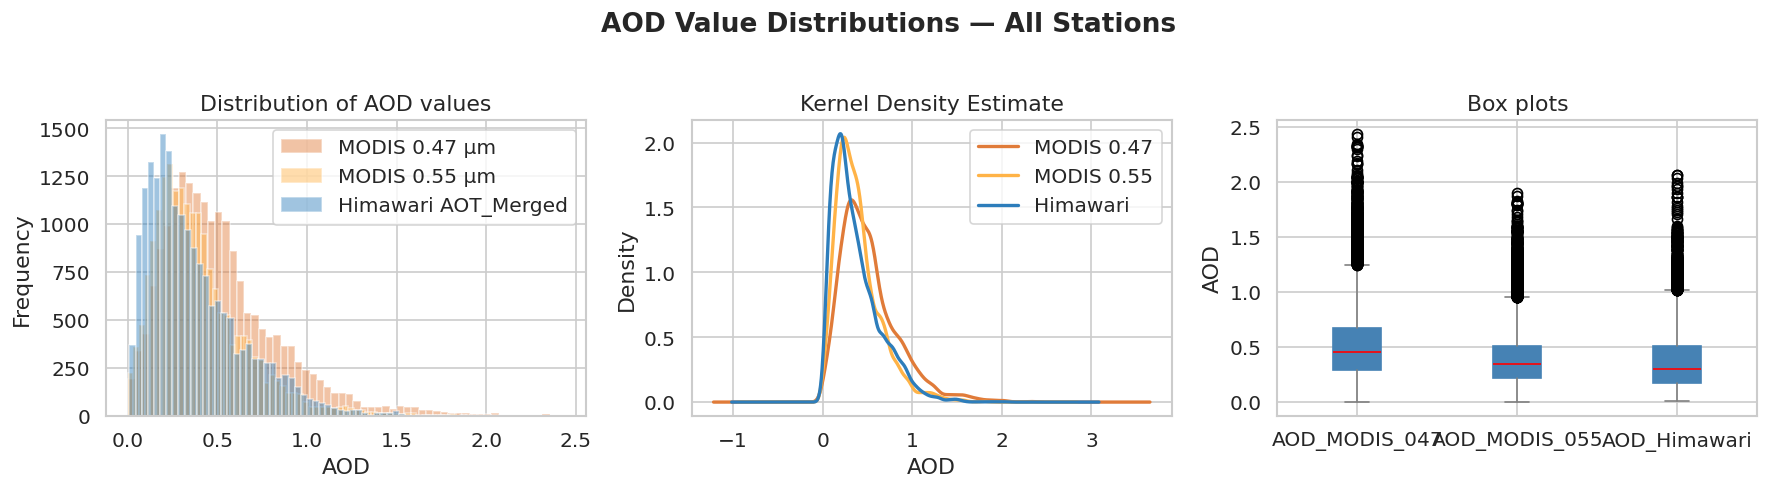

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

modis_cols = [f'AOD_MODIS_{band.split("_")[-1]}' for band in MODIS_BANDS]

# Histograms
for col, color, label in [
    (modis_cols[0], '#E07B39', 'MODIS 0.47 µm'),
    (modis_cols[1], '#FFB347', 'MODIS 0.55 µm'),
    ('AOD_Himawari', '#2D7DBB', 'Himawari AOT_Merged')
]:
    all_df[col].plot.hist(bins=60, alpha=0.45, color=color, label=label, ax=axes[0])
axes[0].set_xlabel('AOD'); axes[0].set_title('Distribution of AOD values')
axes[0].legend()

# KDE
for col, color, label in [(modis_cols[0], '#E07B39', 'MODIS 0.47'),
                           (modis_cols[1], '#FFB347', 'MODIS 0.55'),
                           ('AOD_Himawari', '#2D7DBB', 'Himawari')]:
    all_df[col].plot.kde(ax=axes[1], color=color, lw=2)
axes[1].set_xlabel('AOD'); axes[1].set_title('Kernel Density Estimate')
axes[1].legend([l for _, _, l in [(modis_cols[0], '#E07B39', 'MODIS 0.47'),
                                   (modis_cols[1], '#FFB347', 'MODIS 0.55'),
                                   ('AOD_Himawari', '#2D7DBB', 'Himawari')]])

# Box plots
all_df[[modis_cols[0], modis_cols[1], 'AOD_Himawari']].plot.box(
    ax=axes[2],
    color={'boxes': 'steelblue', 'medians': 'red', 'whiskers': 'gray', 'caps': 'gray'},
    patch_artist=True
)
axes[2].set_title('Box plots'); axes[2].set_ylabel('AOD')

plt.suptitle('AOD Value Distributions — All Stations', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## 6 · Global Correlation Analysis

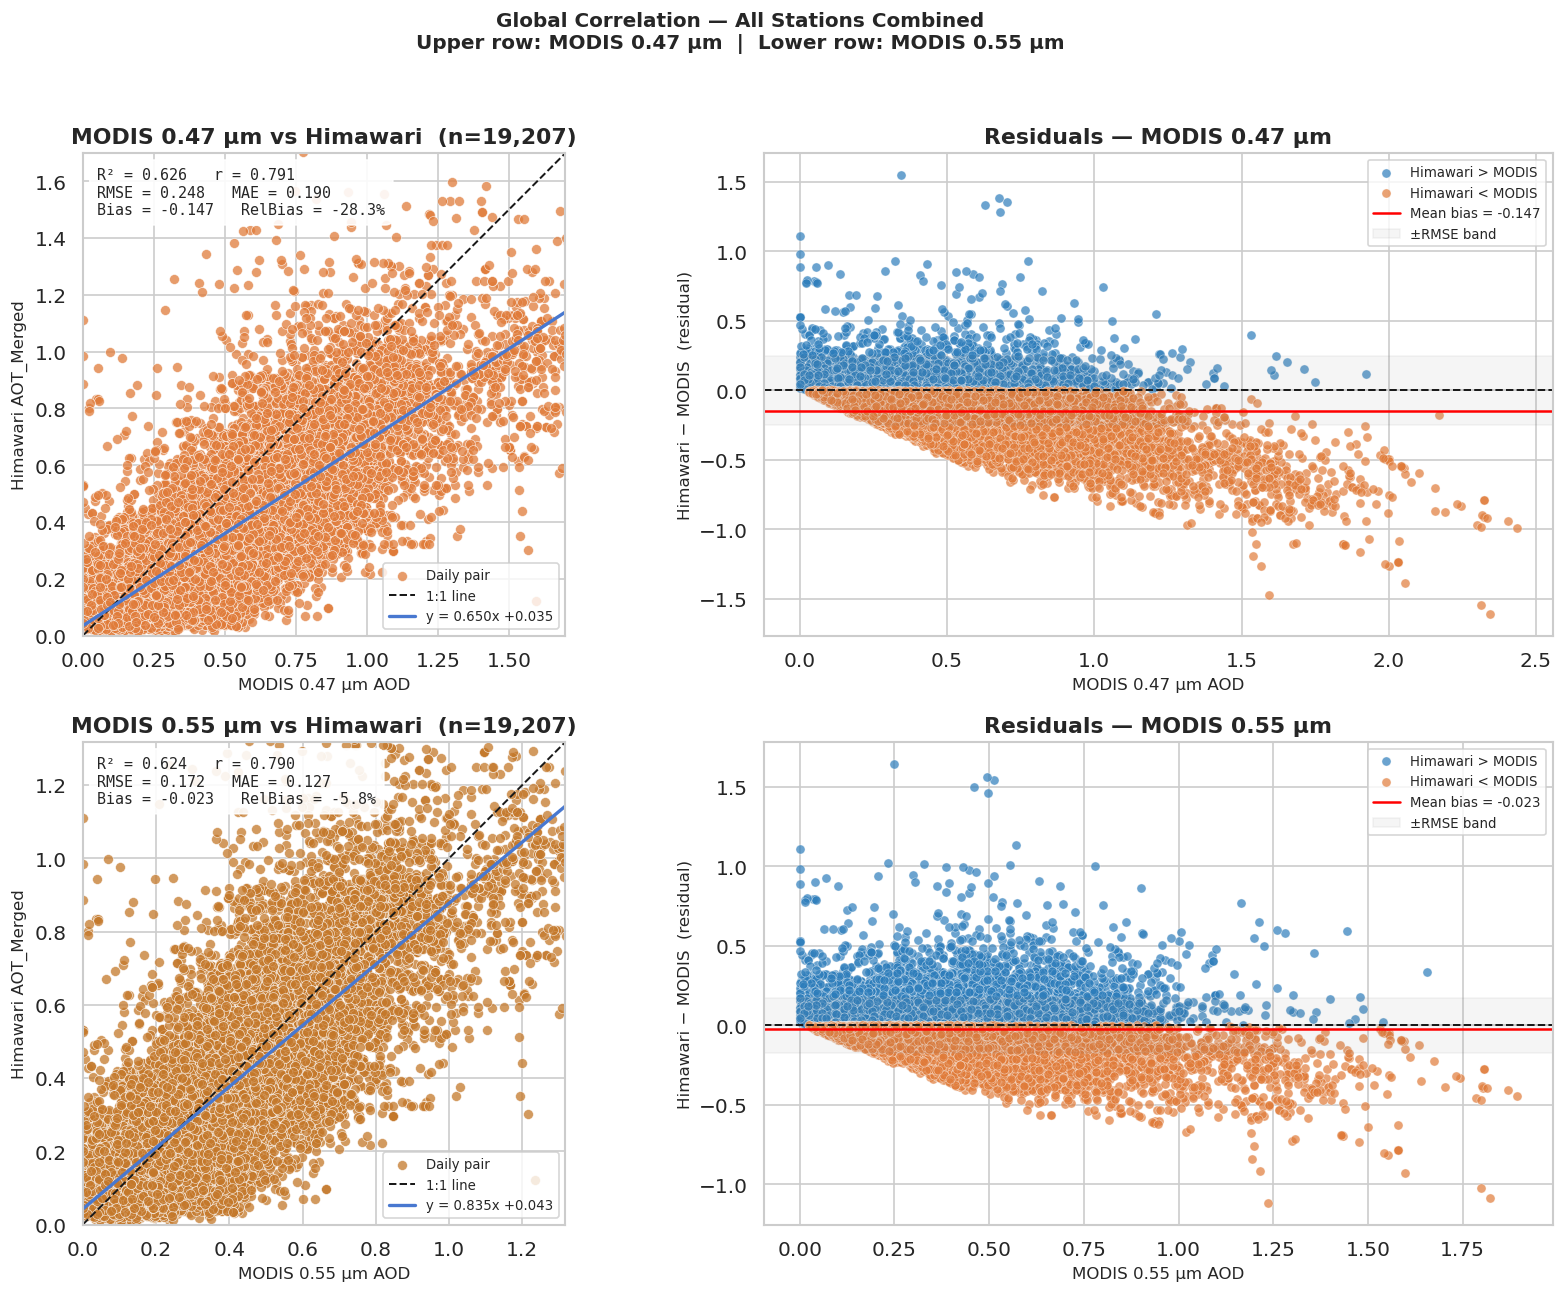

,n,r,R2,slope,intercept,RMSE,MAE,Bias,RelBias_pct
AOD_MODIS_047,19207.0,0.7909,0.6255,0.6503,0.0346,0.2485,0.1895,-0.1469,-28.3012
AOD_MODIS_055,19207.0,0.7899,0.6240,0.8348,0.0425,0.1717,0.1271,-0.0227,-5.7579


In [9]:
def regression_stats(x: pd.Series, y: pd.Series) -> dict:
    """Compute key regression / agreement statistics."""
    mask = x.notna() & y.notna()
    x, y = x[mask].values, y[mask].values
    if len(x) < 3:
        return dict(n=len(x), r=np.nan, R2=np.nan, slope=np.nan,
                    intercept=np.nan, RMSE=np.nan, MAE=np.nan,
                    Bias=np.nan, RelBias_pct=np.nan)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    rmse  = np.sqrt(mean_squared_error(x, y))
    mae   = mean_absolute_error(x, y)
    bias  = np.mean(y - x)           # Himawari − MODIS
    relbias = bias / np.mean(x) * 100
    return dict(n=len(x), r=r, R2=r**2, slope=slope, intercept=intercept,
                RMSE=rmse, MAE=mae, Bias=bias, RelBias_pct=relbias)

plot_pairs = [
    ('AOD_MODIS_047', 'MODIS 0.47 µm', '#E07B39'),
    ('AOD_MODIS_055', 'MODIS 0.55 µm', '#C4782A'),
]

# ── 2×2: left col = scatter+regression, right col = residuals ─────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=False, sharey=False)

gs_dict = {}   # store global stats for both bands

for i, (modis_col, band_label, color) in enumerate(plot_pairs):
    gs = regression_stats(all_df[modis_col], all_df['AOD_Himawari'])
    gs_dict[modis_col] = gs

    # ── Scatter ─────────────────────────────────────────────────────────────
    ax = axes[i, 0]
    valid = all_df[[modis_col, 'AOD_Himawari']].dropna()
    ax.scatter(valid[modis_col], valid['AOD_Himawari'],
               c=color, edgecolors='white', linewidths=0.4, s=35, alpha=0.75,
               label='data pair')

    q99 = max(valid[modis_col].quantile(0.99), valid['AOD_Himawari'].quantile(0.99))
    lims = [0, q99 * 1.05]
    ax.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    xfit = np.linspace(*lims, 200)
    ax.plot(xfit, gs['slope']*xfit + gs['intercept'], 'b-', lw=2,
            label=f"y = {gs['slope']:.3f}x {gs['intercept']:+.3f}")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(f'{band_label} AOD', fontsize=10)
    ax.set_ylabel('Himawari AOT_Merged', fontsize=10)
    ax.set_title(f'{band_label} vs Himawari  (n={gs["n"]:,})', fontweight='bold')
    stats_text = (f"R² = {gs['R2']:.3f}   r = {gs['r']:.3f}\n"
                  f"RMSE = {gs['RMSE']:.3f}   MAE = {gs['MAE']:.3f}\n"
                  f"Bias = {gs['Bias']:+.3f}   RelBias = {gs['RelBias_pct']:+.1f}%")
    ax.text(0.03, 0.97, stats_text, transform=ax.transAxes,
            va='top', ha='left', fontsize=9, fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9))
    ax.legend(fontsize=8, loc='lower right')

    # ── Residuals ────────────────────────────────────────────────────────────
    ax2 = axes[i, 1]
    resid = all_df['AOD_Himawari'] - all_df[modis_col]
    valid_resid = all_df[[modis_col]].dropna().join(resid.rename('resid')).dropna()

    # colour by sign so over/under-estimation is immediately visible
    pos = valid_resid['resid'] >= 0
    ax2.scatter(valid_resid.loc[pos, modis_col], valid_resid.loc[pos, 'resid'],
                c='#2D7DBB', s=30, alpha=0.7, edgecolors='white', lw=0.3,
                label='Himawari > MODIS')
    ax2.scatter(valid_resid.loc[~pos, modis_col], valid_resid.loc[~pos, 'resid'],
                c='#E07B39', s=30, alpha=0.7, edgecolors='white', lw=0.3,
                label='Himawari < MODIS')
    ax2.axhline(0,          color='k',   lw=1.2, linestyle='--')
    ax2.axhline(gs['Bias'], color='red', lw=1.5, linestyle='-',
                label=f"Mean bias = {gs['Bias']:+.3f}")
    # ±RMSE band
    ax2.axhspan(-gs['RMSE'], gs['RMSE'], color='gray', alpha=0.08, label=f'±RMSE band')
    ax2.set_xlabel(f'{band_label} AOD', fontsize=10)
    ax2.set_ylabel('Himawari − MODIS  (residual)', fontsize=10)
    ax2.set_title(f'Residuals — {band_label}', fontweight='bold')
    ax2.legend(fontsize=8)

plt.suptitle('Global Correlation — All Stations Combined\n'
             'Upper row: MODIS 0.47 µm  |  Lower row: MODIS 0.55 µm',
             fontweight='bold', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Summary table for both bands
pd.DataFrame(gs_dict).T.round(4)


## 7 · Per-Station Correlation Statistics

In [10]:
station_stats = []
for sid, df in station_dfs.items():
    if len(df) < 5:
        continue

    for band in MODIS_BANDS:
        col_name = f'AOD_MODIS_{band.split("_")[-1]}'
        s = regression_stats(df[col_name], df['AOD_Himawari'])
        s['station_id'] = sid
        s['band'] = band
        if 'Name' in df.columns:
            s['Name'] = df['Name'].iloc[0]
        station_stats.append(s)

stats_df = pd.DataFrame(station_stats).set_index(['station_id', 'band']).round(4)

print(f'Stations with ≥5 pairs: {stats_df.shape[0]}')
display(stats_df.sort_values(['band','R2'], ascending=[True, False]).head(40))

Stations with ≥5 pairs: 242


,,n,r,R2,slope,intercept,RMSE,MAE,Bias,RelBias_pct,Name
station_id,band,,,,,,,,,,
Quảng Ninh: Km11 - Minh Thành (KK),Optical_Depth_047,131,0.8789,0.7725,0.8253,-0.0652,0.1958,0.1601,-0.1470,-31.3804,Quảng Ninh: Km11 - Minh Thành (KK)
Quảng Ninh: UBND phường Mạo Khê - Đông Triều (KK),Optical_Depth_047,159,0.8683,0.7540,0.7125,-0.0244,0.2124,0.1674,-0.1572,-34.0180,Quảng Ninh: UBND phường Mạo Khê - Đông Triều (KK)
Quảng Ninh: UBND TP Uông Bí (KK),Optical_Depth_047,160,0.8664,0.7507,0.7688,-0.0471,0.2086,0.1667,-0.1551,-33.2032,Quảng Ninh: UBND TP Uông Bí (KK)
Gia Lai: Trạm Diên Phú (KK),Optical_Depth_047,187,0.8651,0.7485,0.8059,0.0112,0.1031,0.0742,-0.0294,-14.0329,Gia Lai: Trạm Diên Phú (KK)
Gia Lai: UBND thị xã An Khê (KK),Optical_Depth_047,59,0.8618,0.7427,0.9533,-0.0437,0.2022,0.1680,-0.0685,-12.8940,Gia Lai: UBND thị xã An Khê (KK)
"Hà Nội: Trường tiểu học Minh Khai, P. Thanh Nhàn (LCS)",Optical_Depth_047,174,0.8609,0.7411,0.7369,-0.0634,0.2729,0.2306,-0.2277,-36.4555,"Hà Nội: Trường tiểu học Minh Khai, P. Thanh Nh..."
Hà Nội: UBND phường Hoàng Liệt(LCS),Optical_Depth_047,186,0.8602,0.7400,0.6564,-0.0189,0.2971,0.2441,-0.2384,-37.3208,Hà Nội: UBND phường Hoàng Liệt(LCS)
Hà Nội: UBND phường Định Công(LCS),Optical_Depth_047,187,0.8589,0.7377,0.6680,-0.0357,0.3071,0.2580,-0.2532,-38.6427,Hà Nội: UBND phường Định Công(LCS)
"Hà Nội: TT văn hoá thể thao Ninh Hiệp, xã Ninh Hiệp(LCS)",Optical_Depth_047,170,0.8547,0.7305,0.6678,0.0287,0.2365,0.1842,-0.1618,-28.2108,"Hà Nội: TT văn hoá thể thao Ninh Hiệp, xã Ninh..."


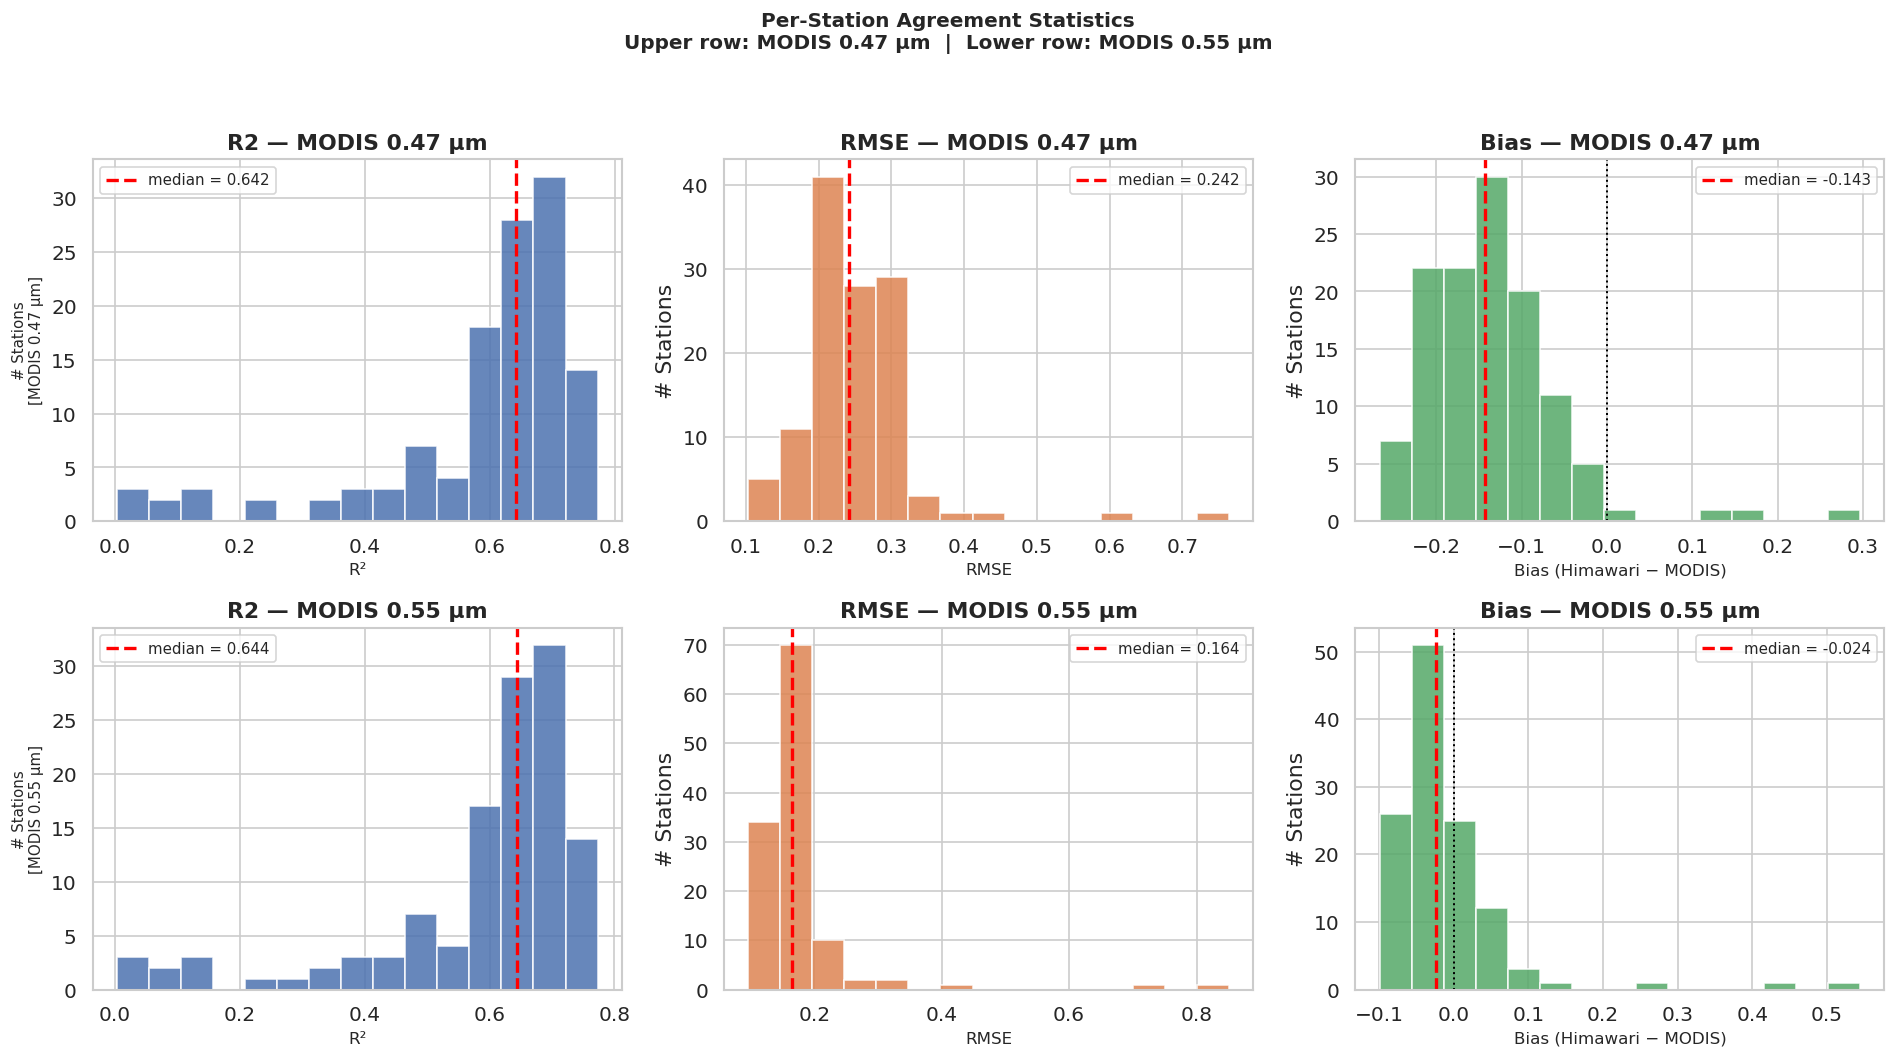

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

band_configs = [
    ('Optical_Depth_047', '0.47 µm', '#E07B39'),
    ('Optical_Depth_055', '0.55 µm', '#C4782A'),
]

for row, (band, band_label, base_color) in enumerate(band_configs):
    band_stats = stats_df.xs(band, level='band')

    for col_idx, (metric, color, xlabel) in enumerate([
        ('R2',   '#4C72B0', 'R²'),
        ('RMSE', '#DD8452', 'RMSE'),
        ('Bias', '#55A868', 'Bias (Himawari − MODIS)'),
    ]):
        ax = axes[row, col_idx]
        data = band_stats[metric].dropna()
        ax.hist(data, bins=min(15, len(data)), color=color, edgecolor='white', alpha=0.85)
        median_val = data.median()
        ax.axvline(median_val, color='red', lw=2, linestyle='--',
                   label=f'median = {median_val:.3f}')
        if metric == 'Bias':
            ax.axvline(0, color='black', lw=1.2, linestyle=':')
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel('# Stations')
        ax.set_title(f'{metric} — MODIS {band_label}', fontweight='bold')
        ax.legend(fontsize=9)

# Row labels
for row, (_, band_label, _) in enumerate(band_configs):
    axes[row, 0].set_ylabel(f'# Stations\n[MODIS {band_label}]', fontsize=9)

plt.suptitle('Per-Station Agreement Statistics\n'
             'Upper row: MODIS 0.47 µm  |  Lower row: MODIS 0.55 µm',
             fontweight='bold', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 8 · Seasonal / Monthly Correlation

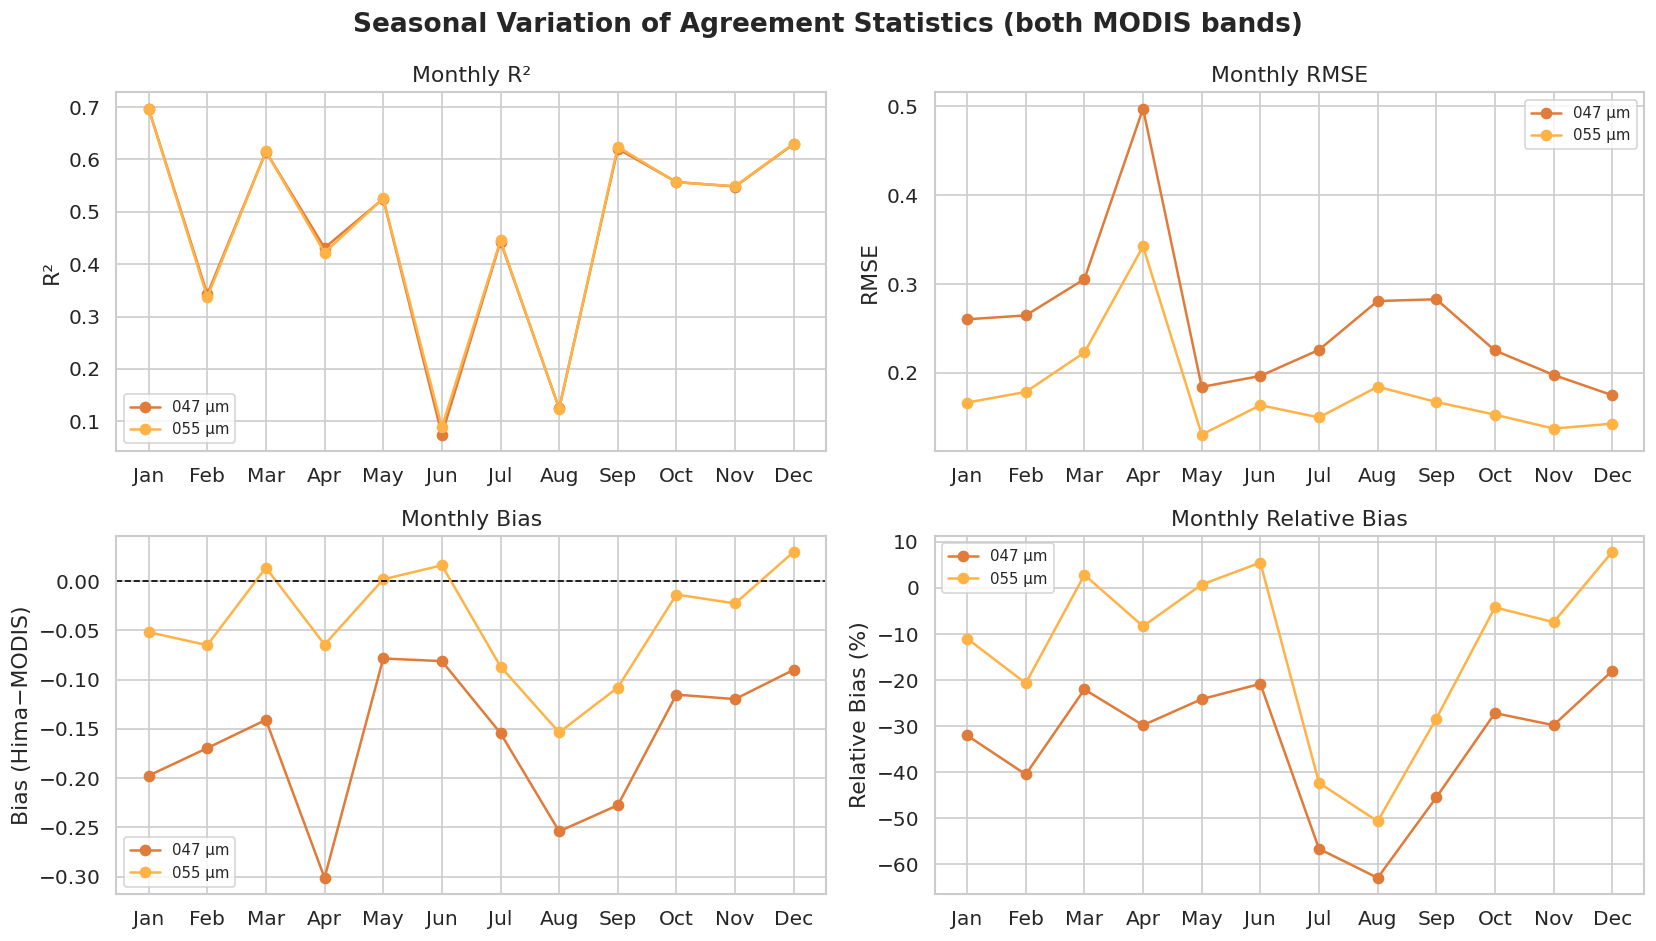

In [12]:
all_df['month'] = all_df['timestamp'].dt.month
all_df['year']  = all_df['timestamp'].dt.year

monthly_dfs = {}
for band in MODIS_BANDS:
    modis_col = f'AOD_MODIS_{band.split("_")[-1]}'
    monthly_stats = []
    for m, grp in all_df.groupby('month'):
        if len(grp) < 10:
            continue
        s = regression_stats(grp[modis_col], grp['AOD_Himawari'])
        s['month'] = m
        monthly_stats.append(s)
    monthly_dfs[band] = pd.DataFrame(monthly_stats).set_index('month')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col, ylabel, title in [
    (axes[0,0], 'R2',           'R²',                'Monthly R²'),
    (axes[0,1], 'RMSE',         'RMSE',              'Monthly RMSE'),
    (axes[1,0], 'Bias',         'Bias (Hima−MODIS)', 'Monthly Bias'),
    (axes[1,1], 'RelBias_pct',  'Relative Bias (%)', 'Monthly Relative Bias'),
]:
    for band, style in [(MODIS_BANDS[0], '#E07B39'), (MODIS_BANDS[1], '#FFB347')]:
        df = monthly_dfs[band]
        ax.plot(df.index, df[col], marker='o', color=style, label=f"{band.split('_')[-1]} µm")
    ax.set_xticks(monthly_dfs[MODIS_BANDS[0]].index)
    ax.set_xticklabels([month_names[m-1] for m in monthly_dfs[MODIS_BANDS[0]].index])
    ax.set_title(title); ax.set_ylabel(ylabel)
    if col == 'Bias':
        ax.axhline(0, color='black', lw=1, linestyle='--')
    ax.legend(fontsize=9)

plt.suptitle('Seasonal Variation of Agreement Statistics (both MODIS bands)', fontweight='bold')
plt.tight_layout(); plt.show()

## 9 · Time-Series Comparison — Top-N Stations

In [13]:
stats_df

n  \
station_id                                         band                     
Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp T... Optical_Depth_047   91   
                                                   Optical_Depth_055   91   
Bình Định: Khuôn viên Cây xanh gần cầu chui đườ... Optical_Depth_047   10   
                                                   Optical_Depth_055   10   
Bình Định: huyện Tuy Phước (KK)                    Optical_Depth_047   11   
...                                                                   ...   
Đà Nẵng: Phạm Hùng (KK)                         Optical_Depth_055  115   
Đà Nẵng: 41 đường Lê Duẩn (KK)                     Optical_Depth_047   99   
                                                   Optical_Depth_055   99   
Đà Nẵng: Khuôn viên trường ĐH sư phạm Đà Nẵng (KK) Optical_Depth_047   58   
                                                   Optical_Depth_055   58   

                                                                           r  \
station_id                                         band                        
Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp T... Optical_Depth_047  0.5681   
                                                   Optical_Depth_055  0.5690   
Bình Định: Khuôn viên Cây xanh gần cầu chui đườ... Optical_Depth_047  0.2840   
                                                   Optical_Depth_055  0.2845   
Bình Định: huyện Tuy Phước (KK)                    Optical_Depth_047  0.0529   
...                                                                      ...   
Đà Nẵng: Phạm Hùng (KK)                         Optical_Depth_055  0.7046   
Đà Nẵng: 41 đường Lê Duẩn (KK)                     Optical_Depth_047  0.6165   
                                                   Optical_Depth_055  0.6232   
Đà Nẵng: Khuôn viên trường ĐH sư phạm Đà Nẵng (KK) Optical_Depth_047  0.5083   
                                                   Optical_Depth_055  0.5121   

                                                                          R2  \
station_id                                         band                        
Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp T... Optical_Depth_047  0.3228   
                                                   Optical_Depth_055  0.3238   
Bình Định: Khuôn viên Cây xanh gần cầu chui đườ... Optical_Depth_047  0.0806   
                                                   Optical_Depth_055  0.0809   
Bình Định: huyện Tuy Phước (KK)                    Optical_Depth_047  0.0028   
...                                                                      ...   
Đà Nẵng: Phạm Hùng (KK)                         Optical_Depth_055  0.4964   
Đà Nẵng: 41 đường Lê Duẩn (KK)                     Optical_Depth_047  0.3800   
                                                   Optical_Depth_055  0.3884   
Đà Nẵng: Khuôn viên trường ĐH sư phạm Đà Nẵng (KK) Optical_Depth_047  0.2583   
                                                   Optical_Depth_055  0.2623   

                                                                       slope  \
station_id                                         band                        
Bình Dương: số 593 Đại lộ Bình Dương, P. Hiệp T... Optical_Depth_047  0.3592   
                                                   Optical_Depth_055  0.4899   
Bình Định: Khuôn viên Cây xanh gần cầu chui đườ... Optical_Depth_047  0.4414   
                                                   Optical_Depth_055  0.5807   
Bình Định: huyện Tuy Phước (KK)                    Optical_Depth_047  0.0755   
...                                                                      ...   
Đà Nẵng: Phạm Hùng (KK)                         Optical_Depth_055  0.7358   
Đà Nẵng: 41 đường Lê Duẩn (KK)                     Optical_Depth_047  0.4333   
                                                   Optical_Depth_055  0.5596   
Đà Nẵng: Khuôn viên trường ĐH sư phạm Đà Nẵng (KK) Optical_Depth_047  0.3731   
                            

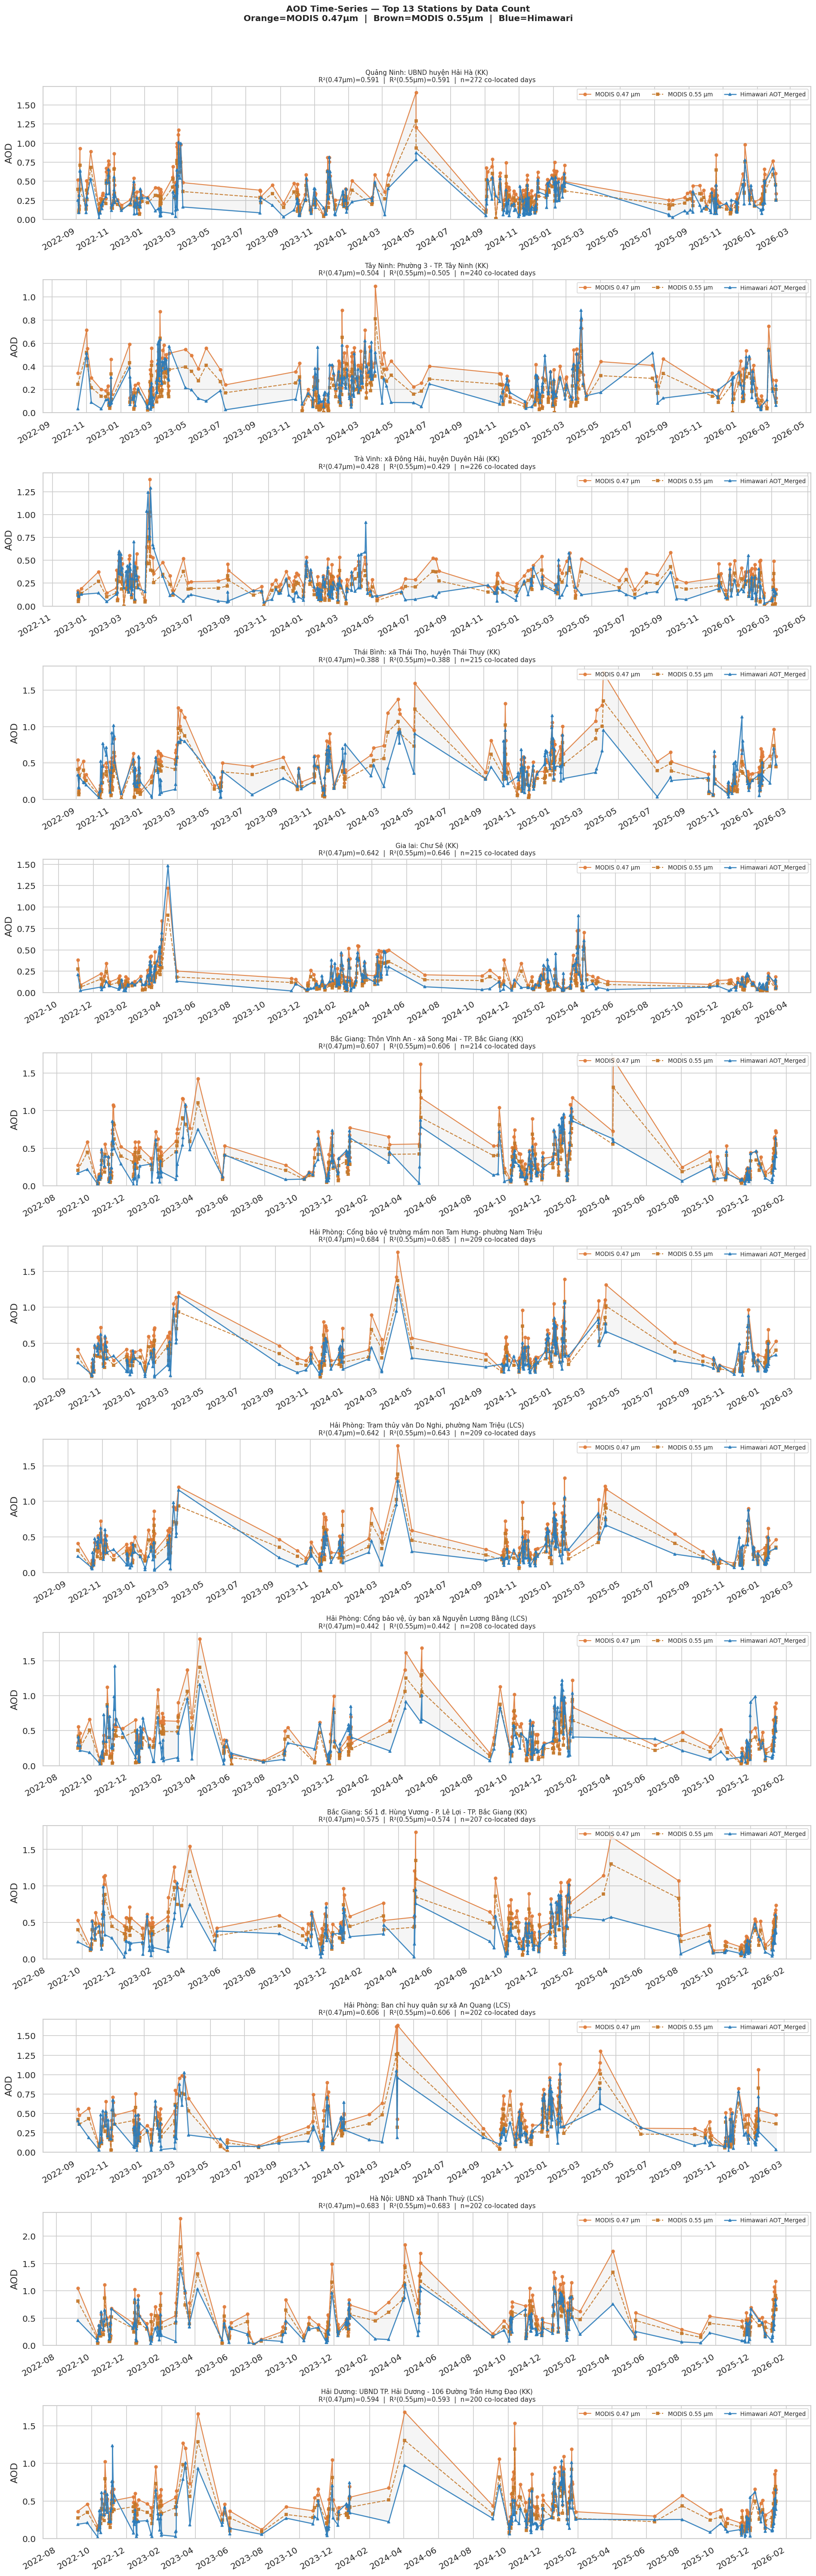

In [14]:
TOP_N = 13   # adjust as needed

# stats_df has MultiIndex (station_id, band); get unique stations by max n
n_by_station = all_df.groupby('station_id').size().sort_values(ascending=False)
top_stations = n_by_station.head(TOP_N).index.tolist()

fig, axes = plt.subplots(TOP_N, 1, figsize=(16, 3.8 * TOP_N), sharex=False)
if TOP_N == 1:
    axes = [axes]

for ax, sid in zip(axes, top_stations):
    df = station_dfs[sid]
    name = df['Name'].iloc[0] if 'Name' in df.columns else sid

    # ── Plot all three series on the same axes ─────────────────────────────
    ax.plot(df.index, df['AOD_MODIS_047'], 'o-', color='#E07B39', ms=4, lw=1.3,
            label='MODIS 0.47 µm', alpha=0.9)
    ax.plot(df.index, df['AOD_MODIS_055'], 's-', color='#C4782A', ms=4, lw=1.3,
            label='MODIS 0.55 µm', alpha=0.9, linestyle='--')
    ax.plot(df.index, df['AOD_Himawari'],  '^-', color='#2D7DBB', ms=4, lw=1.5,
            label='Himawari AOT_Merged', alpha=0.9)

    # Shade gap between 047 and Himawari to make bias visible
    ax.fill_between(df.index, df['AOD_MODIS_047'], df['AOD_Himawari'],
                    alpha=0.08, color='gray')

    # Per-band R² from stats_df
    def _r2(sid, band):
        key = (sid, band)
        return f"{stats_df.loc[key, 'R2']:.3f}" if key in stats_df.index else 'N/A'

    r2_047 = _r2(sid, 'Optical_Depth_047')
    r2_055 = _r2(sid, 'Optical_Depth_055')
    n = df[['AOD_MODIS_047', 'AOD_Himawari']].dropna().shape[0]

    ax.set_title(
        f"{str(name)[:65]}\n"
        f"R²(0.47µm)={r2_047}  |  R²(0.55µm)={r2_055}  |  n={n} co-located days",
        fontsize=9
    )
    ax.set_ylabel('AOD')
    ax.legend(fontsize=8, loc='upper right', ncol=3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylim(bottom=0)

plt.suptitle(f'AOD Time-Series — Top {TOP_N} Stations by Data Count\n'
             'Orange=MODIS 0.47µm  |  Brown=MODIS 0.55µm  |  Blue=Himawari',
             fontweight='bold', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 10 · Interative Station Selector

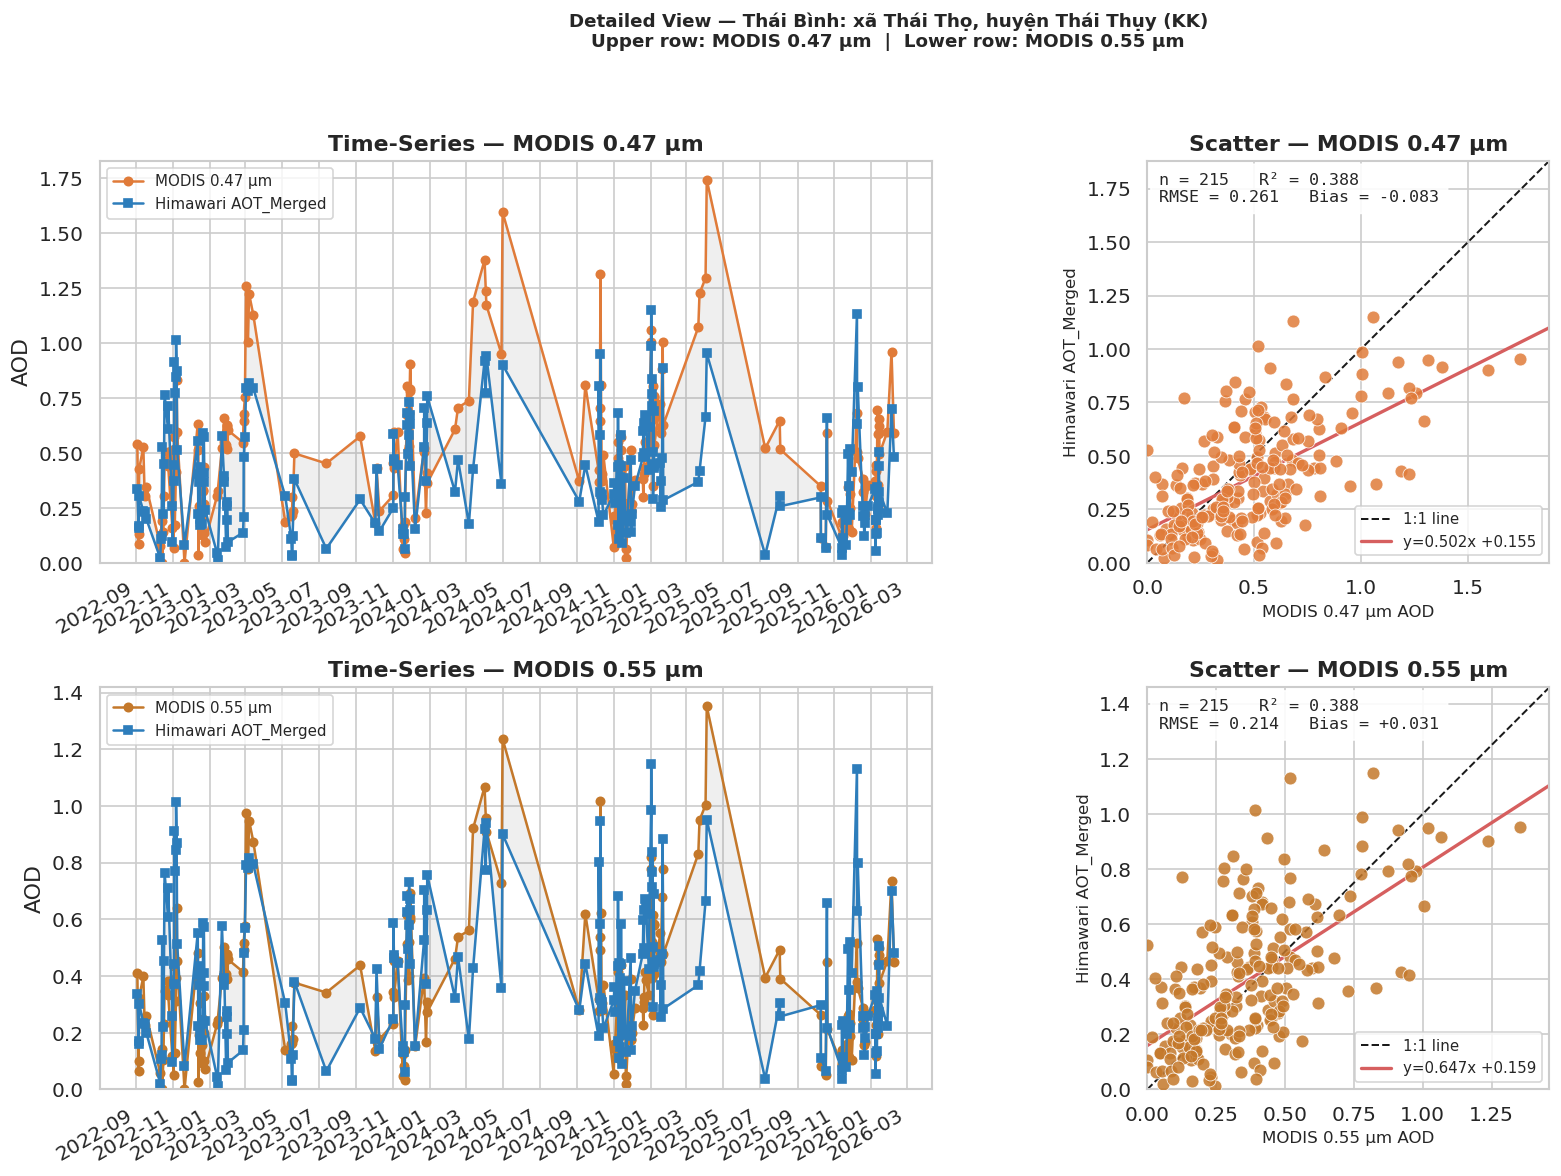

In [15]:
# Change STATION_ID to inspect any station in detail
STATION_ID = top_stations[3]   # ← replace with any station ID string

df  = station_dfs[STATION_ID]
name = df['Name'].iloc[0] if 'Name' in df.columns else STATION_ID

band_configs = [
    ('AOD_MODIS_047', 'MODIS 0.47 µm', '#E07B39', 'Optical_Depth_047'),
    ('AOD_MODIS_055', 'MODIS 0.55 µm', '#C4782A', 'Optical_Depth_055'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for row, (modis_col, band_label, color, band_key) in enumerate(band_configs):
    s = regression_stats(df[modis_col], df['AOD_Himawari'])

    # ── Time-series ─────────────────────────────────────────────────────────
    ax = axes[row, 0]
    ax.plot(df.index, df[modis_col],    'o-', color=color,    ms=5, lw=1.5, label=band_label)
    ax.plot(df.index, df['AOD_Himawari'], 's-', color='#2D7DBB', ms=5, lw=1.5,
            label='Himawari AOT_Merged')
    ax.fill_between(df.index, df[modis_col], df['AOD_Himawari'],
                    alpha=0.12, color='gray', label='_gap')
    ax.set_title(f'Time-Series — {band_label}', fontweight='bold')
    ax.set_ylabel('AOD')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_ylim(bottom=0)

    # ── Scatter ─────────────────────────────────────────────────────────────
    ax2 = axes[row, 1]
    valid = df[[modis_col, 'AOD_Himawari']].dropna()
    ax2.scatter(valid[modis_col], valid['AOD_Himawari'],
                c=color, edgecolors='white', linewidths=0.5, s=60, alpha=0.85,
                zorder=3)
    lim_max = max(valid[modis_col].max(), valid['AOD_Himawari'].max()) * 1.08
    lims = [0, lim_max]
    ax2.plot(lims, lims, 'k--', lw=1.2, label='1:1 line')
    xfit = np.linspace(*lims, 200)
    ax2.plot(xfit, s['slope']*xfit + s['intercept'], 'r-', lw=2,
             label=f"y={s['slope']:.3f}x {s['intercept']:+.3f}")
    ax2.set_xlim(lims); ax2.set_ylim(lims)
    ax2.set_aspect('equal', adjustable='box')
    ax2.set_xlabel(f'{band_label} AOD', fontsize=10)
    ax2.set_ylabel('Himawari AOT_Merged', fontsize=10)
    ax2.set_title(f'Scatter — {band_label}', fontweight='bold')
    stats_text = (f"n = {s['n']}   R² = {s['R2']:.3f}\n"
                  f"RMSE = {s['RMSE']:.3f}   Bias = {s['Bias']:+.3f}")
    ax2.text(0.03, 0.97, stats_text, transform=ax2.transAxes,
             va='top', fontsize=10, fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.9))
    ax2.legend(fontsize=9, loc='lower right')

plt.suptitle(
    f'Detailed View — {str(name)[:70]}\n'
    f'Upper row: MODIS 0.47 µm  |  Lower row: MODIS 0.55 µm',
    fontweight='bold', fontsize=11
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 11 · Global Time-Series (Monthly Mean, All Stations)

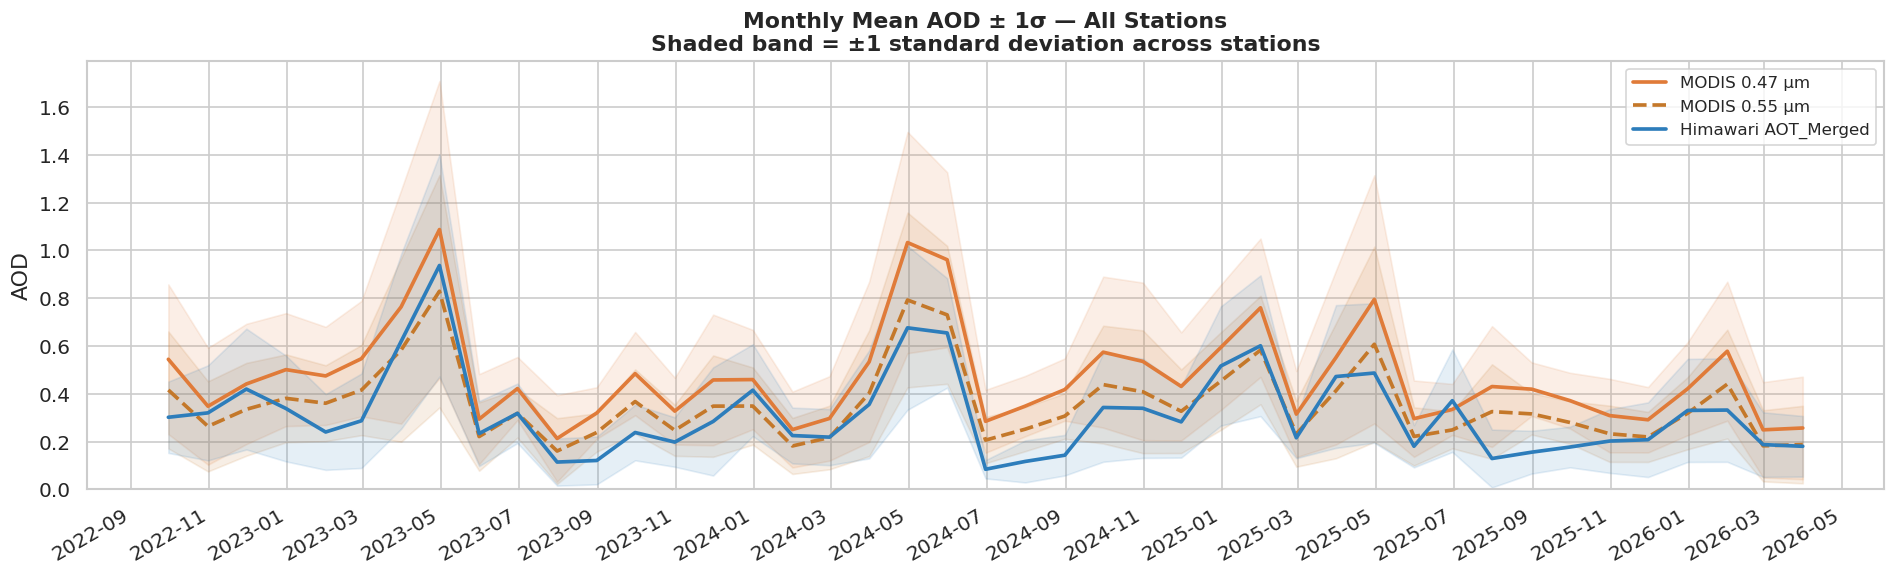

In [16]:
cols_to_plot = ['AOD_MODIS_047', 'AOD_MODIS_055', 'AOD_Himawari']

monthly_mean = (
    all_df.set_index('timestamp')[cols_to_plot]
    .resample('1ME')
    .agg(['mean', 'std'])
)
monthly_mean.columns = ['_'.join(c) for c in monthly_mean.columns]

fig, ax = plt.subplots(figsize=(16, 5))

series_cfg = [
    ('AOD_MODIS_047', '#E07B39', 'MODIS 0.47 µm',  '-'),
    ('AOD_MODIS_055', '#C4782A', 'MODIS 0.55 µm',  '--'),
    ('AOD_Himawari',  '#2D7DBB', 'Himawari AOT_Merged', '-'),
]

for col, color, label, ls in series_cfg:
    mu  = monthly_mean[f'{col}_mean']
    sig = monthly_mean[f'{col}_std']
    ax.plot(mu.index, mu, color=color, lw=2.2, linestyle=ls, label=label, zorder=3)
    ax.fill_between(mu.index, (mu - sig).clip(lower=0), mu + sig,
                    color=color, alpha=0.12)

ax.set_title('Monthly Mean AOD ± 1σ — All Stations\n'
             'Shaded band = ±1 standard deviation across stations',
             fontweight='bold')
ax.set_ylabel('AOD')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


## 12 · Heatmap — R² by Station × Month

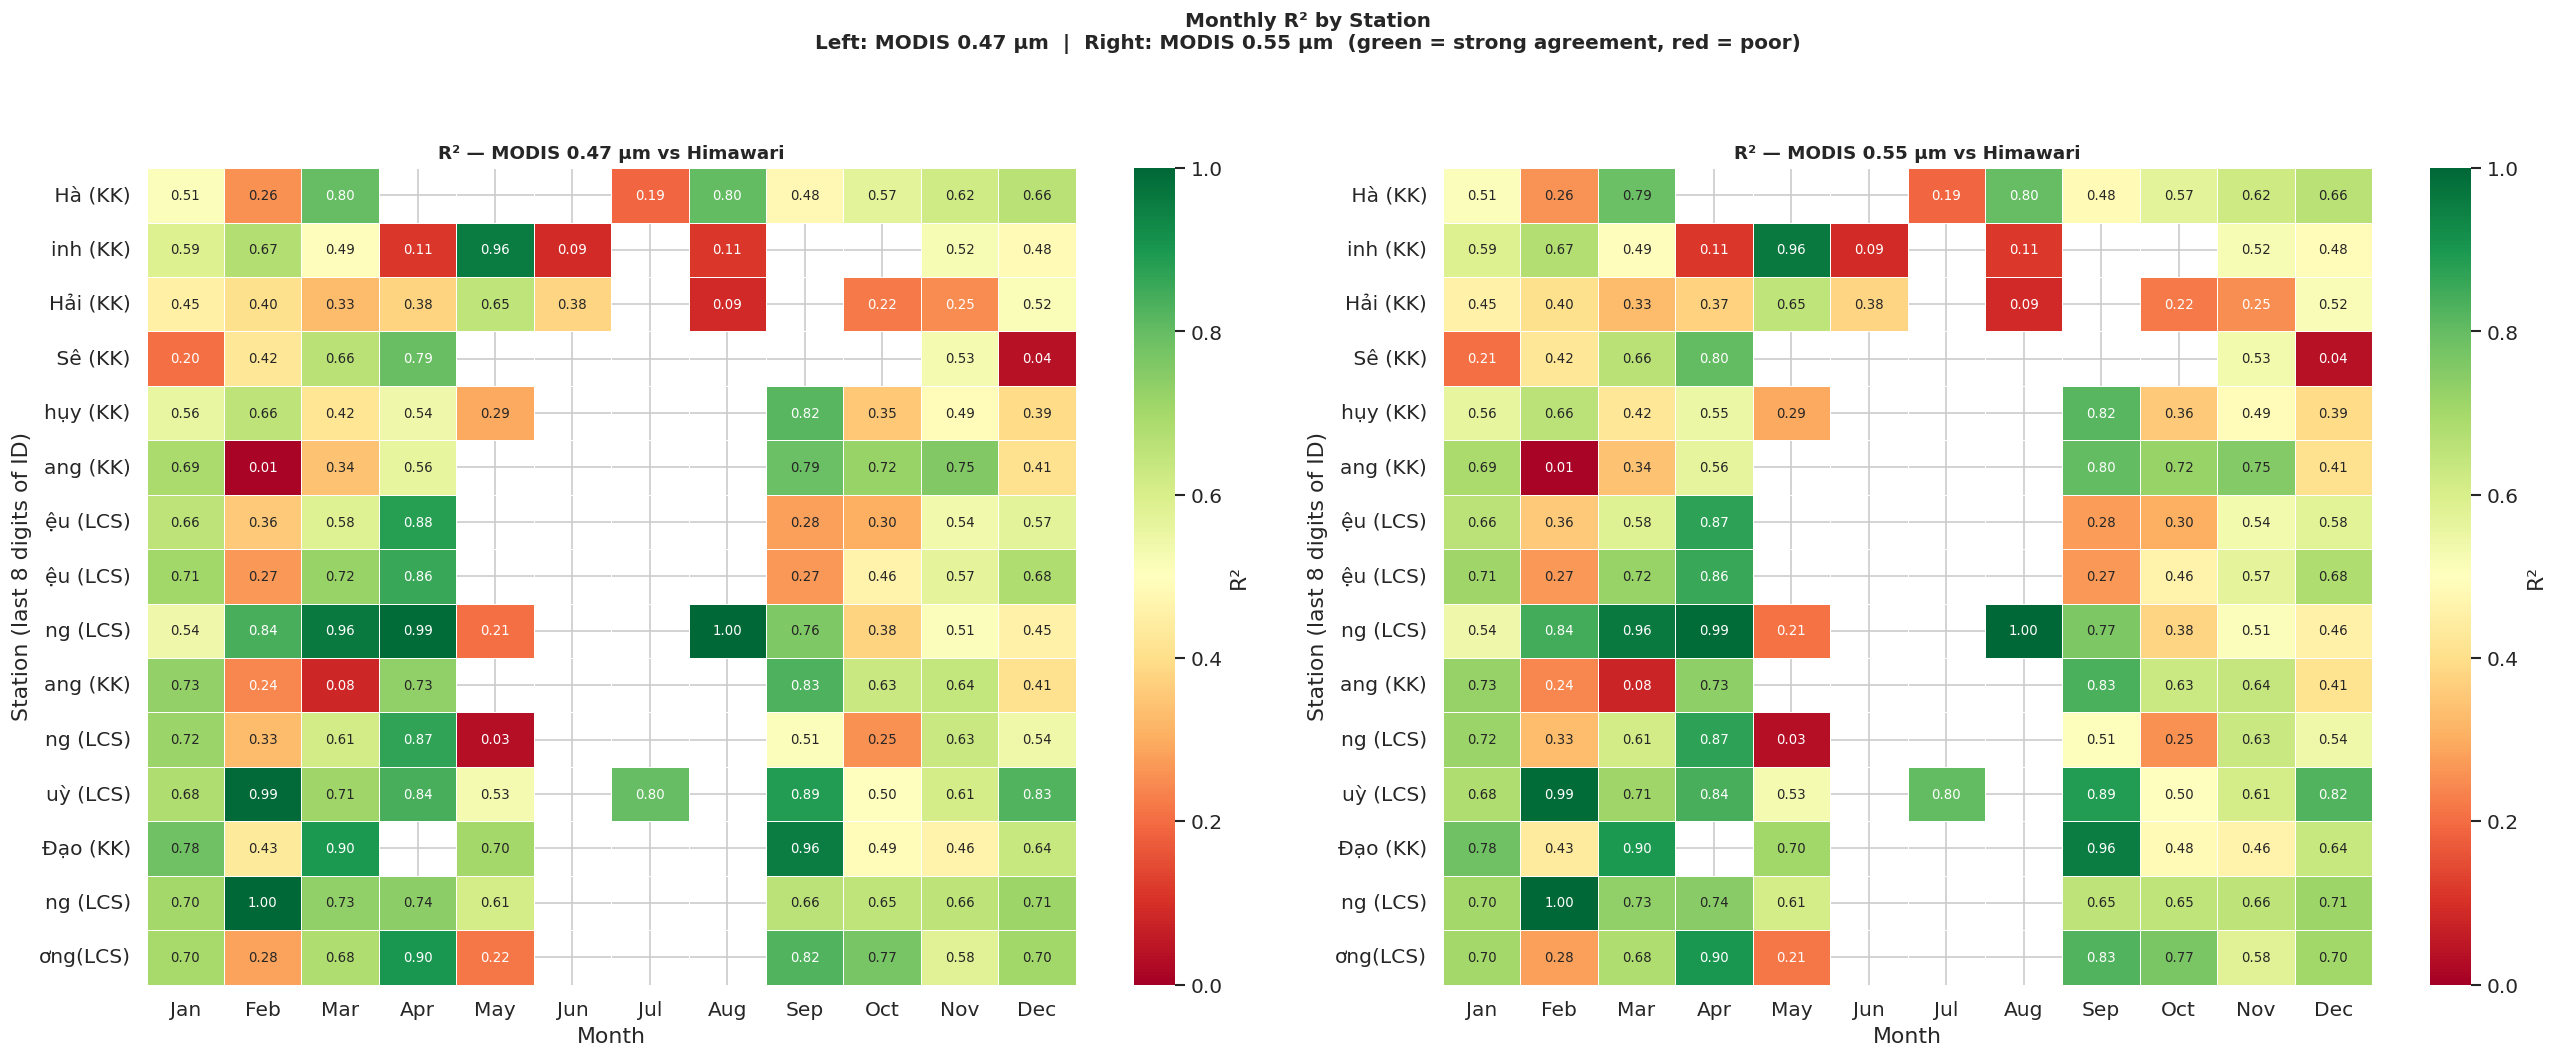

In [17]:
MIN_MONTHLY_N = 3

# Use station IDs with n >= 10 in at least one band
station_n = stats_df.groupby(level='station_id')['n'].max()
HEATMAP_STATIONS = station_n[station_n >= 10].sort_values(ascending=False).head(15).index.tolist()

band_pairs = [
    ('Optical_Depth_047', 'AOD_MODIS_047', 'MODIS 0.47 µm'),
    ('Optical_Depth_055', 'AOD_MODIS_055', 'MODIS 0.55 µm'),
]

fig, axes = plt.subplots(1, 2, figsize=(22, max(4, len(HEATMAP_STATIONS) * 0.6)))

for ax, (band_key, modis_col, band_label) in zip(axes, band_pairs):
    pivot_r2 = pd.DataFrame(index=HEATMAP_STATIONS, columns=range(1, 13), dtype=float)

    for sid in HEATMAP_STATIONS:
        df = station_dfs[sid].copy()
        df['month'] = df.index.month
        for m, grp in df.groupby('month'):
            valid = grp[[modis_col, 'AOD_Himawari']].dropna()
            if len(valid) >= MIN_MONTHLY_N:
                r, _ = stats.pearsonr(valid[modis_col], valid['AOD_Himawari'])
                pivot_r2.loc[sid, m] = round(r**2, 3)

    pivot_r2.columns = [month_names[m-1] for m in pivot_r2.columns]
    # Use last 8 digits of station ID as short label
    pivot_r2.index = [str(s)[-8:] for s in pivot_r2.index]

    sns.heatmap(
        pivot_r2.astype(float), annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=0, vmax=1,
        linewidths=0.5, ax=ax, cbar_kws={'label': 'R²'},
        annot_kws={'size': 8}
    )
    ax.set_title(f'R² — {band_label} vs Himawari', fontweight='bold', fontsize=11)
    ax.set_xlabel('Month')
    ax.set_ylabel('Station (last 8 digits of ID)')

plt.suptitle('Monthly R² by Station\n'
             'Left: MODIS 0.47 µm  |  Right: MODIS 0.55 µm  '
             '(green = strong agreement, red = poor)',
             fontweight='bold', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


## 13 · Summary Table — Export

In [18]:
export_path = 'AOD_station_correlation_summary.csv'
stats_df.sort_values(['band', 'R2'], ascending=[True, False]).to_csv(export_path)
print(f'Saved → {export_path}')

# Per-band global stats
gs_047 = regression_stats(all_df['AOD_MODIS_047'], all_df['AOD_Himawari'])
gs_055 = regression_stats(all_df['AOD_MODIS_055'], all_df['AOD_Himawari'])
stats_047 = stats_df.xs('Optical_Depth_047', level='band')
stats_055 = stats_df.xs('Optical_Depth_055', level='band')

summary = {
    'Metric': [
        'N co-located records', 'N stations',
        'Median R²  (0.47 µm)', 'Median R²  (0.55 µm)',
        'Median RMSE (0.47 µm)', 'Median RMSE (0.55 µm)',
        'Global Bias  (0.47 µm)  Hima−MODIS',
        'Global Bias  (0.55 µm)  Hima−MODIS',
        'Stations R²≥0.7  (0.47 µm)',
        'Stations R²≥0.7  (0.55 µm)',
    ],
    'Value': [
        f"{len(all_df):,}",
        f"{all_df['station_id'].nunique()}",
        f"{stats_047['R2'].median():.3f}",
        f"{stats_055['R2'].median():.3f}",
        f"{stats_047['RMSE'].median():.3f}",
        f"{stats_055['RMSE'].median():.3f}",
        f"{gs_047['Bias']:+.3f}  ({gs_047['RelBias_pct']:+.1f}%)",
        f"{gs_055['Bias']:+.3f}  ({gs_055['RelBias_pct']:+.1f}%)",
        f"{(stats_047['R2'] >= 0.7).sum()} / {len(stats_047)}",
        f"{(stats_055['R2'] >= 0.7).sum()} / {len(stats_055)}",
    ]
}
display(pd.DataFrame(summary).set_index('Metric'))


Saved → AOD_station_correlation_summary.csv


,Value
Metric,
N co-located records,"19,207"
N stations,121
Median R² (0.47 µm),0.642
Median R² (0.55 µm),0.644
Median RMSE (0.47 µm),0.242
Median RMSE (0.55 µm),0.164
Global Bias (0.47 µm) Hima−MODIS,-0.147 (-28.3%)
Global Bias (0.55 µm) Hima−MODIS,-0.023 (-5.8%)
Stations R²≥0.7 (0.47 µm),26 / 121
